In [1]:
# Install dependency
!pip install -q scikit-learn Sastrawi matplotlib seaborn wordcloud pandas numpy joblib

In [2]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
fname = list(uploaded.keys())[0]
print('File terupload:', fname)
pd.read_csv(fname).head()

Saving Dataset penelitian DSAI(3000) Update.csv to Dataset penelitian DSAI(3000) Update (1).csv
File terupload: Dataset penelitian DSAI(3000) Update (1).csv


,author,comment,manual_sentiment
0,@chandrawangsawijaya7545,kak hebaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa...,positive
1,@deanwf3087,Bogos binted,neutral
2,@Maverick-wb1do,Edit : bumi ke alpha centauri 4.2 tahun cahaya...,neutral
3,@kyokoonam,Nadanya bikin merinding ya😁,positive
4,@royzena2108,Kita harus bisa buat teleporter,neutral


In [3]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support
)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

warnings.filterwarnings('ignore')

# ----- Gaya plot -----
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.dpi'] = 120

# ----- Konstanta global -----
RS = 42
ORDER = ['negative', 'neutral', 'positive']
PAL = {'negative': '#E74C3C', 'neutral': '#95A5A6', 'positive': '#2ECC71'}

os.makedirs('figures', exist_ok=True)


def savefig(name):
    """Simpan figure aktif ke ./figures lalu tampilkan."""
    plt.tight_layout()
    plt.savefig(f'figures/{name}.png', bbox_inches='tight')
    plt.show()


# ----- Pengaturan -----
DATASET_PATH = 'Dataset penelitian DSAI(3000) Update.csv'
USE_STEMMING = False        # False = sesuai paper. Ubah True utk uji A/B efek Sastrawi.
SHOW_RBF_BASELINE = True    # tampilkan RBF cuma sbg pembanding (tidak dipakai sbg model final)

## 1) LOAD DATA

In [4]:
df = pd.read_csv(DATASET_PATH)
df = df[['author', 'comment', 'manual_sentiment']].dropna(subset=['comment', 'manual_sentiment'])
df['manual_sentiment'] = df['manual_sentiment'].str.lower().str.strip()
df = df[df['manual_sentiment'].isin(ORDER)].copy()

print('Jumlah data:', len(df))
print(df['manual_sentiment'].value_counts())

Jumlah data: 3000
manual_sentiment
neutral     1068
positive     999
negative     933
Name: count, dtype: int64


## 2) PREPROCESSING (tanpa stemming; emoji jadi token; negation handling)

In [5]:
# Kamus normalisasi kata gaul/singkatan -> bentuk baku
slang = {
    # negasi
    'gak': 'tidak', 'ga': 'tidak', 'gk': 'tidak', 'nggak': 'tidak',
    'ngga': 'tidak', 'enggak': 'tidak', 'tdk': 'tidak', 'tak': 'tidak', 'engga': 'tidak',
    # kata umum & partikel
    'udah': 'sudah', 'udh': 'sudah', 'blm': 'belum', 'aja': 'saja', 'aj': 'saja',
    'bgt': 'banget', 'bngt': 'banget', 'yg': 'yang', 'dgn': 'dengan',
    # kata tanya & konjungsi
    'utk': 'untuk', 'klo': 'kalau', 'kalo': 'kalau', 'gmn': 'bagaimana',
    'gimana': 'bagaimana', 'knp': 'kenapa', 'krn': 'karena', 'karna': 'karena',
    # kata umum lain
    'jd': 'jadi', 'jdi': 'jadi', 'nih': 'ini', 'tuh': 'itu', 'org': 'orang',
    'bgs': 'bagus', 'mantul': 'mantap', 'gokil': 'keren', 'kerenn': 'keren',
    # istilah YouTube & kata ganti orang
    'vidio': 'video', 'vid': 'video', 'sub': 'subscribe', 'min': 'admin',
    'gw': 'saya', 'gue': 'saya', 'gua': 'saya', 'lu': 'kamu', 'lo': 'kamu',
    'elu': 'kamu', 'ane': 'saya', 'ente': 'kamu',
    # sisanya
    'sgt': 'sangat', 'dr': 'dari', 'sy': 'saya', 'tp': 'tapi', 'tpi': 'tapi',
}

POS_EMO = set('😍🥰😘❤️♥️💕👍🔥🎉😊🙏👏🤩😭🥹✨💯🥳😂🤣💖🙌👌🥲😀😁😃😄')
NEG_EMO = set('😡🤬👎😠💩🤮😤😒🙄😞😔💔😢😣😩😫🙁')
NEG_WORDS = {'tidak', 'bukan', 'jangan', 'belum', 'tanpa', 'kurang'}

stemmer = StemmerFactory().create_stemmer()
stop_words = set(StopWordRemoverFactory().get_stop_words()) - NEG_WORDS - {'tapi', 'sangat', 'paling'}

url_re = re.compile(r'http\S+|www\.\S+')
mention_re = re.compile(r'@\w+|#\w+')
nonword_re = re.compile(r'[^a-z\s]')
elong_re = re.compile(r'(.)\1{2,}')


def preprocess(text):
    """Bersihkan satu komentar mentah menjadi token siap-TFIDF.

    Alurnya: lowercase -> hitung emoji -> hapus URL/mention -> rapikan huruf
    berulang -> buang karakter non-huruf -> normalisasi slang -> buang
    stopword -> (opsional) stemming -> gabungkan kata negasi dengan kata
    sesudahnya -> tambahkan token penanda emoji.
    """
    t = str(text).lower()

    n_pos = sum(t.count(e) for e in POS_EMO)
    n_neg = sum(t.count(e) for e in NEG_EMO)

    t = url_re.sub(' ', t)
    t = mention_re.sub(' ', t)
    t = elong_re.sub(r'\1', t)
    t = nonword_re.sub(' ', t)
    t = re.sub(r'\s+', ' ', t).strip()

    tokens = [slang.get(w, w) for w in t.split()]
    tokens = [w for w in tokens if w not in stop_words and len(w) > 1]
    t = ' '.join(tokens)

    if USE_STEMMING:
        t = stemmer.stem(t)

    # Gabungkan kata negasi dgn kata sesudahnya, mis. "tidak bagus" -> "tidak_bagus"
    toks = t.split()
    out = []
    i = 0
    while i < len(toks):
        if toks[i] in NEG_WORDS and i + 1 < len(toks):
            out.append(toks[i] + '_' + toks[i + 1])
            i += 2
        else:
            out.append(toks[i])
            i += 1

    out += ['emopos'] * min(n_pos, 3) + ['emoneg'] * min(n_neg, 3)
    return ' '.join(out)


print(f'\nPreprocessing (USE_STEMMING={USE_STEMMING})...')
df['clean'] = df['comment'].apply(preprocess)
df = df[df['clean'].str.len() > 0].copy()
print('Sisa data:', len(df))


Preprocessing (USE_STEMMING=False)...
Sisa data: 2943


## 3) FITUR: Dual TF-IDF (kata 1-2 + karakter 2-5)

In [6]:
X, y = df['clean'], df['manual_sentiment']
Xtr_txt, Xte_txt, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RS, stratify=y
)

word_vec = TfidfVectorizer(
    analyzer='word', ngram_range=(1, 2), max_features=15000,
    min_df=2, sublinear_tf=True
)
char_vec = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(2, 5), max_features=20000,
    min_df=3, sublinear_tf=True
)
feats = FeatureUnion([('word', word_vec), ('char', char_vec)])

Xtr = feats.fit_transform(Xtr_txt)
Xte = feats.transform(Xte_txt)
print('Dimensi fitur:', Xtr.shape[1])

Dimensi fitur: 18656


## 4) MODEL LINEAR + ENSEMBLE  (TANPA RBF sebagai model final)


=== Perbandingan Model (Akurasi CV) ===
  Ensemble (soft-vote)            : 75.83%
  SVM-RBF (baseline, tdk dipakai) : 75.74%
  LogReg                          : 75.11%
  LinearSVC                       : 75.11%
  ComplementNB                    : 74.00%


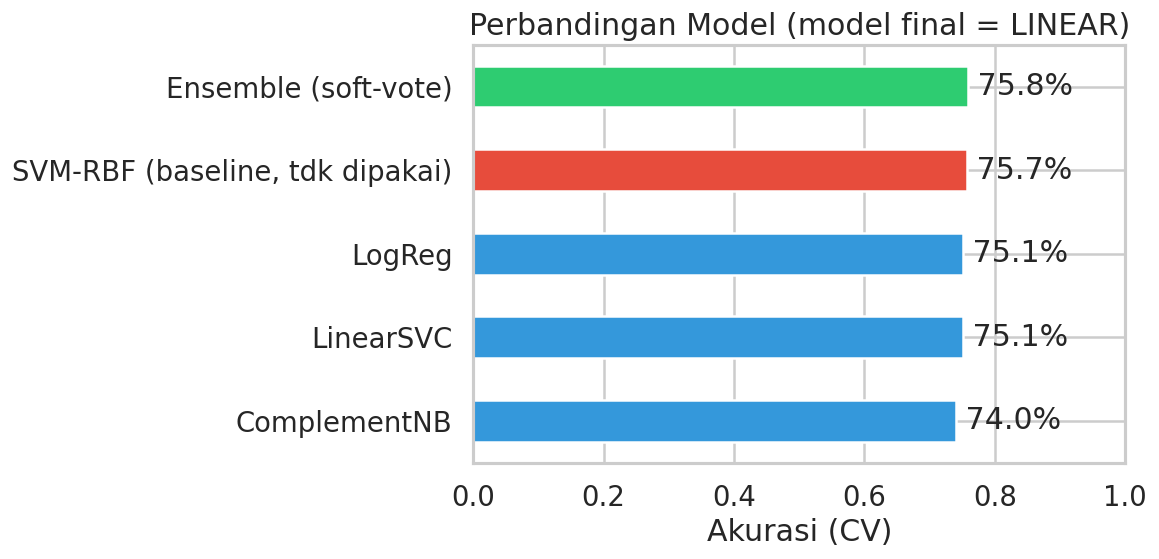


Model final terpilih (linear): Ensemble (soft-vote)


VotingClassifier(estimators=[('logreg',
                              LogisticRegression(C=1, class_weight='balanced',
                                                 max_iter=3000,
                                                 random_state=42)),
                             ('linsvc',
                              CalibratedClassifierCV(estimator=LinearSVC(C=0.5,
                                                                         class_weight='balanced',
                                                                         max_iter=5000,
                                                                         random_state=42))),
                             ('cnb', ComplementNB(alpha=0.3))],
                 voting='soft')

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)

logreg = LogisticRegression(C=1, class_weight='balanced', max_iter=3000, random_state=RS)
linsvc = CalibratedClassifierCV(
    LinearSVC(C=0.5, class_weight='balanced', random_state=RS, max_iter=5000)
)  # calibrated -> bisa dipakai soft voting
cnb = ComplementNB(alpha=0.3)
ensemble = VotingClassifier(
    estimators=[('logreg', logreg), ('linsvc', linsvc), ('cnb', cnb)],
    voting='soft'
)

candidates = {
    'LogReg': logreg,
    'LinearSVC': linsvc,
    'ComplementNB': cnb,
    'Ensemble (soft-vote)': ensemble,
}
if SHOW_RBF_BASELINE:
    candidates['SVM-RBF (baseline, tdk dipakai)'] = SVC(
        kernel='rbf', C=10, gamma='scale', class_weight='balanced', random_state=RS
    )

scores = {
    name: cross_val_score(model, Xtr, y_train, cv=cv, scoring='accuracy').mean()
    for name, model in candidates.items()
}

print('\n=== Perbandingan Model (Akurasi CV) ===')
for name, score in sorted(scores.items(), key=lambda x: -x[1]):
    print(f'  {name:32s}: {score * 100:.2f}%')

# ---- Bar chart perbandingan akurasi CV ----
plt.figure(figsize=(10, 5))
sm = pd.Series(scores).sort_values()
colors = [
    '#E74C3C' if 'RBF' in n else '#2ECC71' if 'Ensemble' in n else '#3498DB'
    for n in sm.index
]
ax = sm.plot(kind='barh', color=colors)
plt.xlabel('Akurasi (CV)')
plt.title('Perbandingan Model (model final = LINEAR)')
for i, v in enumerate(sm):
    ax.text(v, i, f' {v * 100:.1f}%', va='center')
plt.xlim(0, 1)
savefig('04_perbandingan_model')

# ---- Pilih model final terbaik DI ANTARA yang LINEAR (RBF dikecualikan) ----
linear_only = {name: score for name, score in scores.items() if 'RBF' not in name}
best_name = max(linear_only, key=linear_only.get)
clf = candidates[best_name]

print('\nModel final terpilih (linear):', best_name)
clf.fit(Xtr, y_train)

## 5) EVALUASI TEST


>>> AKURASI TEST: 76.06% <<<

               precision    recall  f1-score   support

    negative     0.7184    0.6793    0.6983       184
     neutral     0.7512    0.7805    0.7656       205
    positive     0.8069    0.8150    0.8109       200

    accuracy                         0.7606       589
   macro avg     0.7588    0.7583    0.7583       589
weighted avg     0.7599    0.7606    0.7600       589



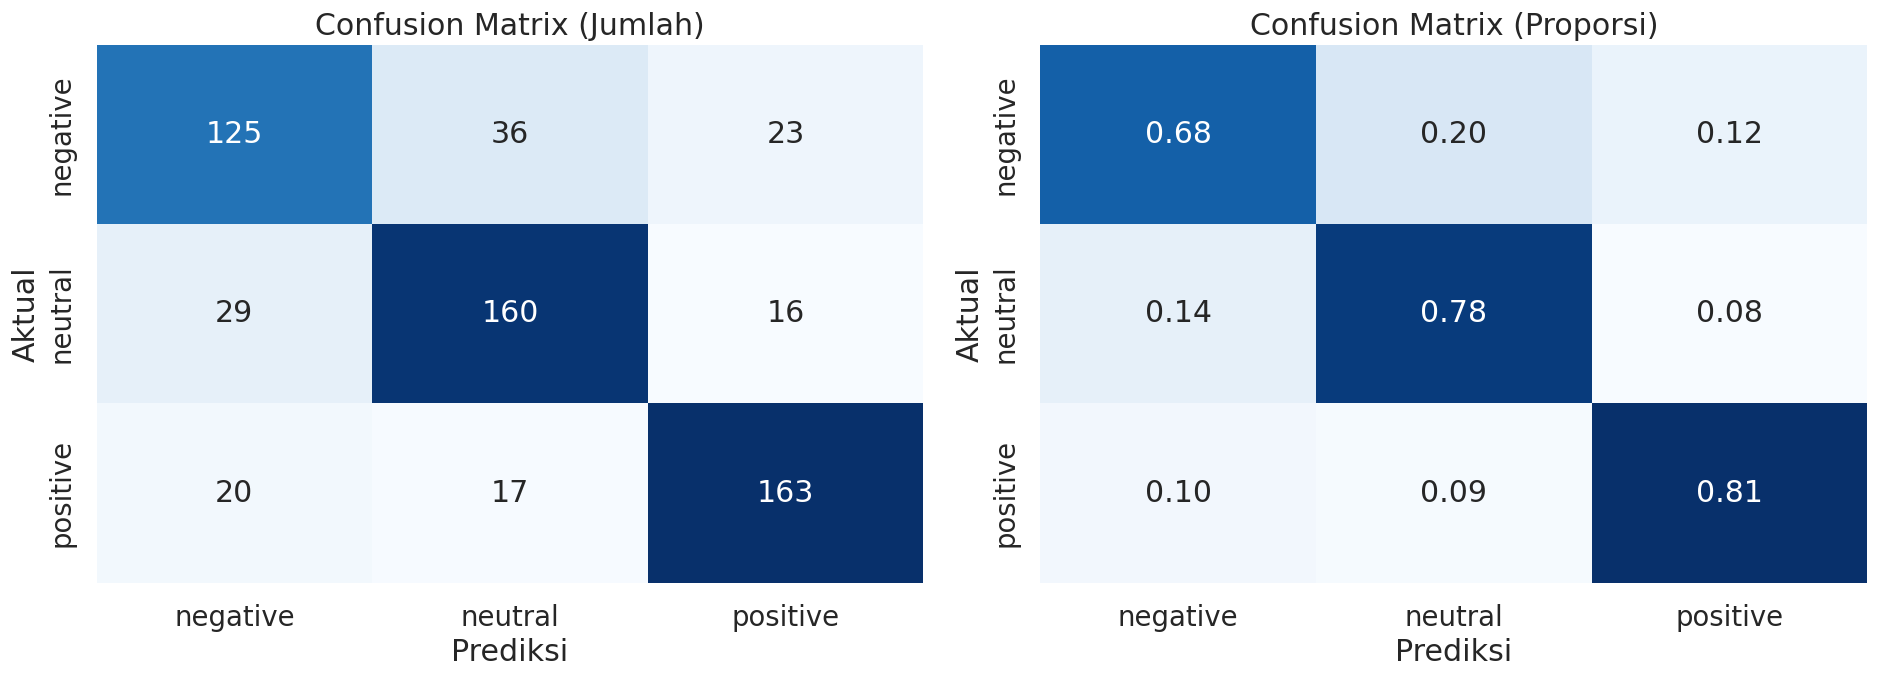

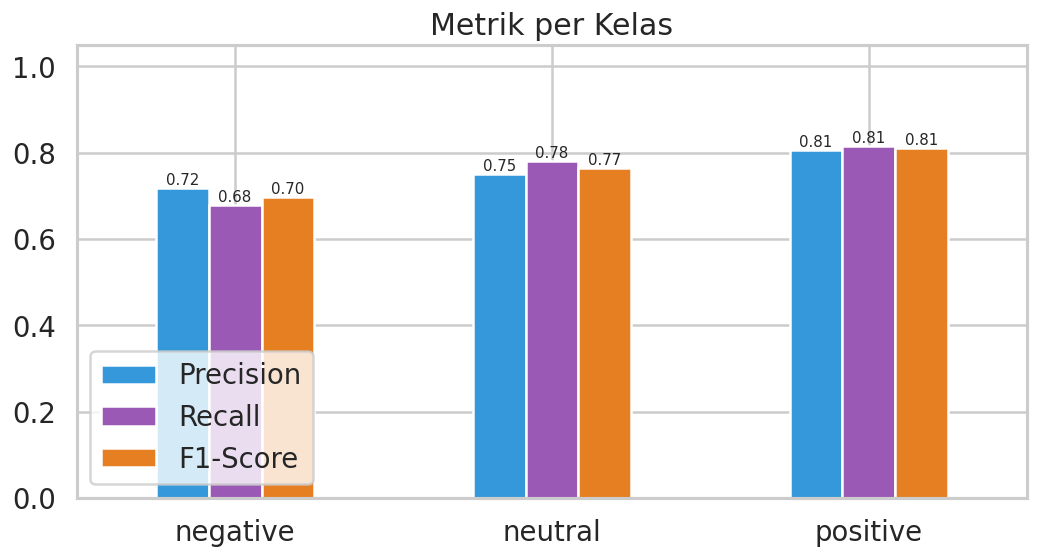

In [8]:
y_pred = clf.predict(Xte)

print(f'\n>>> AKURASI TEST: {accuracy_score(y_test, y_pred) * 100:.2f}% <<<')
print('\n', classification_report(y_test, y_pred, digits=4))

# ---- Confusion matrix: jumlah & proporsi ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cm_configs = [
    (axes[0], None, 'Confusion Matrix (Jumlah)', 'd'),
    (axes[1], 'true', 'Confusion Matrix (Proporsi)', '.2f'),
]
for ax, norm, title, fmt in cm_configs:
    cm = confusion_matrix(y_test, y_pred, labels=ORDER, normalize=norm)
    sns.heatmap(
        cm, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=ORDER, yticklabels=ORDER, ax=ax, cbar=False
    )
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')
    ax.set_title(title)
savefig('05_confusion_matrix')

# ---- Precision / Recall / F1 per kelas ----
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, labels=ORDER)
met = pd.DataFrame({'Precision': prec, 'Recall': rec, 'F1-Score': f1}, index=ORDER)

ax = met.plot(kind='bar', figsize=(9, 5), color=['#3498DB', '#9B59B6', '#E67E22'])
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.title('Metrik per Kelas')
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', fontsize=9)
savefig('06_metrik_per_kelas')

## 6) CROSS-VALIDATION final (angka utama paper)

In [9]:
import joblib

Xall = feats.transform(X)
cv_acc = cross_val_score(clf, Xall, y, cv=cv, scoring='accuracy')
cv_f1 = cross_val_score(clf, Xall, y, cv=cv, scoring='f1_macro')

print(f'\n5-Fold CV Accuracy : {cv_acc.mean() * 100:.2f}% +/- {cv_acc.std() * 100:.2f}%')
print(f'5-Fold CV F1-macro : {cv_f1.mean() * 100:.2f}% +/- {cv_f1.std() * 100:.2f}%')

joblib.dump({'model': clf, 'features': feats}, 'model_svm_v31.joblib')
print('\nSelesai! Grafik di ./figures, model di model_svm_v31.joblib')


5-Fold CV Accuracy : 76.35% +/- 1.25%
5-Fold CV F1-macro : 76.28% +/- 1.27%

Selesai! Grafik di ./figures, model di model_svm_v31.joblib


 3-Fold -> Acc 74.86% +/- 0.71% | F1 74.79%
 5-Fold -> Acc 76.35% +/- 1.25% | F1 76.28%
10-Fold -> Acc 76.35% +/- 1.77% | F1 76.27%

=== Ringkasan Variasi K-Fold ===
 k (folds)  Mean Acc (%)  Std (%)  Min (%)  Max (%)  Mean F1 (%)
         3         74.86     0.71    74.01    75.74        74.79
         5         76.35     1.25    74.87    78.57        76.28
        10         76.35     1.77    74.58    80.61        76.27


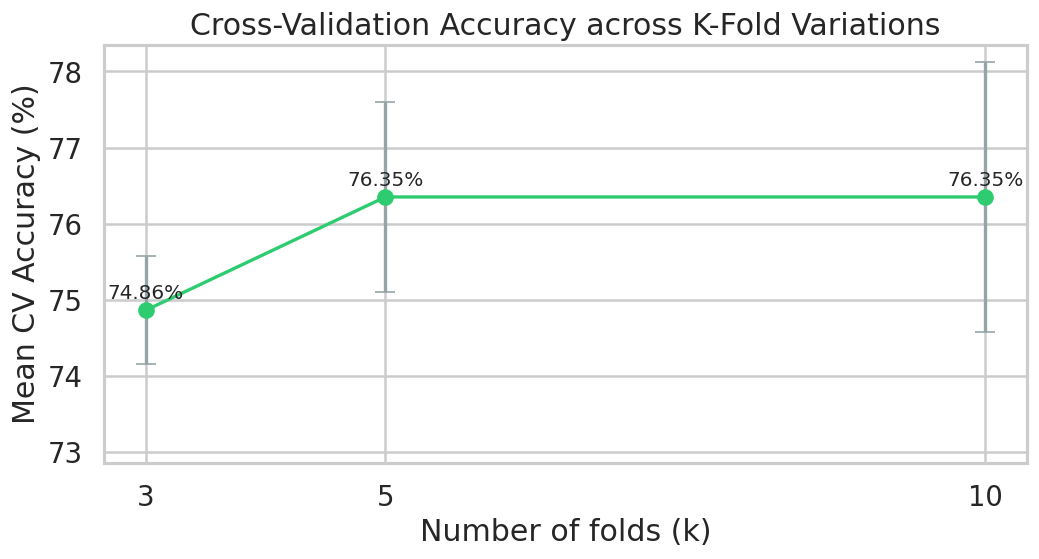

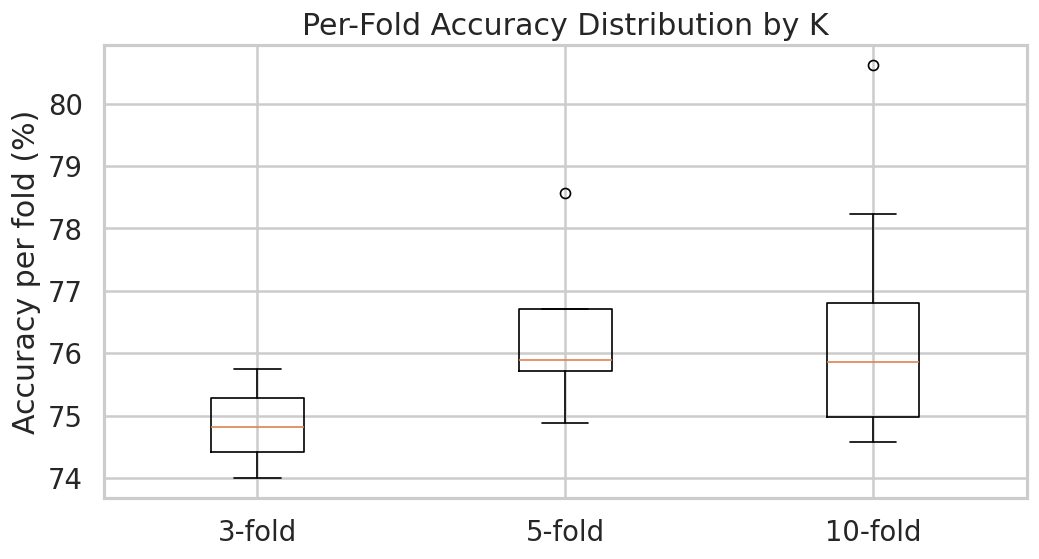


PER-FOLD ACCURACY:
  3-fold: [np.float64(74.01), np.float64(75.74), np.float64(74.82)]
  5-fold: [np.float64(74.87), np.float64(75.89), np.float64(75.72), np.float64(78.57), np.float64(76.7)]
  10-fold: [np.float64(74.92), np.float64(76.61), np.float64(74.58), np.float64(76.87), np.float64(75.85), np.float64(75.85), np.float64(80.61), np.float64(74.83), np.float64(75.17), np.float64(78.23)]


In [10]:
# ============================================================
# VARIASI K-FOLD (3, 5, 10)
# Jalankan SETELAH Cell 8 (butuh: clf, Xall, y, RS, pd, plt, savefig)
# ============================================================
K_VALUES = [3, 5, 10]
kfold_rows, perfold = [], {}

for k in K_VALUES:
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=RS)
    acc = cross_val_score(clf, Xall, y, cv=skf, scoring='accuracy')
    f1 = cross_val_score(clf, Xall, y, cv=skf, scoring='f1_macro')
    perfold[k] = acc
    kfold_rows.append({
        'k (folds)': k,
        'Mean Acc (%)': round(acc.mean() * 100, 2),
        'Std (%)': round(acc.std() * 100, 2),
        'Min (%)': round(acc.min() * 100, 2),
        'Max (%)': round(acc.max() * 100, 2),
        'Mean F1 (%)': round(f1.mean() * 100, 2),
    })
    print(f'{k:>2}-Fold -> Acc {acc.mean()*100:.2f}% +/- {acc.std()*100:.2f}% | F1 {f1.mean()*100:.2f}%')

kfold_df = pd.DataFrame(kfold_rows)
print('\n=== Ringkasan Variasi K-Fold ===')
print(kfold_df.to_string(index=False))

# ---- Line chart: mean accuracy vs k (pakai error bar std) ----
plt.figure(figsize=(9, 5))
means = [r['Mean Acc (%)'] for r in kfold_rows]
stds = [r['Std (%)'] for r in kfold_rows]
plt.errorbar(
    K_VALUES, means, yerr=stds, marker='o', markersize=9, linewidth=2,
    color='#2ECC71', ecolor='#95A5A6', capsize=6
)
for k, m in zip(K_VALUES, means):
    plt.text(k, m + 0.15, f'{m:.2f}%', ha='center', fontsize=12)
plt.xticks(K_VALUES)
plt.xlabel('Number of folds (k)')
plt.ylabel('Mean CV Accuracy (%)')
plt.title('Cross-Validation Accuracy across K-Fold Variations')
plt.ylim(min(means) - 2, max(means) + 2)
savefig('07_kfold_variation_line')

# ---- (opsional) boxplot distribusi akurasi tiap fold ----
plt.figure(figsize=(9, 5))
plt.boxplot([perfold[k] * 100 for k in K_VALUES], labels=[f'{k}-fold' for k in K_VALUES])
plt.ylabel('Accuracy per fold (%)')
plt.title('Per-Fold Accuracy Distribution by K')
savefig('08_kfold_boxplot')

# ---- Angka mentah per fold ----
print('\nPER-FOLD ACCURACY:')
for k in K_VALUES:
    print(f'  {k}-fold:', [round(a * 100, 2) for a in perfold[k]])